# Candidate sites — slope & aspect

Visualizes the slope magnitude and orientation (aspect) of the 123 landslide
candidate points, sampled from the 30 m Copernicus DEM (`data/terrain/la-guaira_dem.tif`).

Fields on `Candidate sites`:
- `slope_deg`  — slope magnitude in degrees (computed in projected meters)
- `aspect_deg` — downslope azimuth, 0–360° (0/360 = N, 90 = E, 180 = S, 270 = W)
- `aspect_dir` — the azimuth binned to an 8-point compass direction

The headline plot is a **stacked slope-rose**: each wedge points the way sites
face, its length is the number of sites, and the colored stack shows their
slope-steepness makeup — so count, orientation, and magnitude appear together.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import geopandas as gpd

CANDIDATES = "../data/landslide_candidates/la-guaira_20260626_150535_17_3010.geojson"
gdf = gpd.read_file(CANDIDATES)
gdf = gdf[gdf["slope_deg"].notna() & gdf["aspect_deg"].notna()].copy()
print(f"{len(gdf)} sites with slope + aspect")
gdf[["site_no", "slope_deg", "aspect_deg", "aspect_dir"]].describe(include="all")

123 sites with slope + aspect


,site_no,slope_deg,aspect_deg,aspect_dir
count,123.000000,123.000000,123.000000,123
unique,NaN,NaN,NaN,8
top,NaN,NaN,NaN,N
freq,NaN,NaN,NaN,28
mean,62.000000,29.300000,158.886179,NaN
std,35.651087,10.744431,123.458509,NaN
min,1.000000,1.100000,0.000000,NaN
25%,31.500000,22.250000,47.000000,NaN
50%,62.000000,27.800000,116.000000,NaN
75%,92.500000,37.100000,291.500000,NaN


## Slope-steepness bins
Grouped into interpretable classes for the stacked rose.

In [2]:
SLOPE_BINS = [0, 10, 20, 30, 40, 90]
SLOPE_LABELS = ["<10° gentle", "10–20°", "20–30°", "30–40° steep", "≥40° very steep"]
# sequential yellow→red: steeper = hotter
SLOPE_COLORS = ["#ffffb2", "#fecc5c", "#fd8d3c", "#f03b20", "#bd0026"]
gdf["slope_bin"] = np.digitize(gdf["slope_deg"], SLOPE_BINS[1:-1])  # 0..4

## Headline: stacked slope-rose (count × orientation × magnitude)

16 petals (N, NNE, NE, …). Petal length = number of sites facing that way;
each petal is stacked and colored by slope class. Compass orientation is
geographic (N up, clockwise).

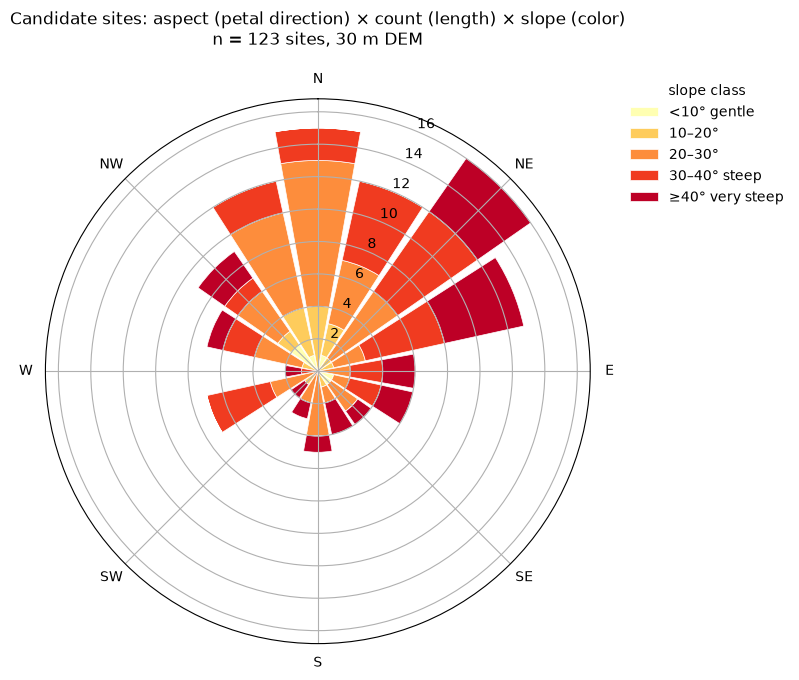

In [3]:
N_PETALS = 16
petal_width = 2 * np.pi / N_PETALS
# bin azimuths into 16 sectors centered on N
sector = np.floor(((gdf["aspect_deg"] + (360 / N_PETALS / 2)) % 360) / (360 / N_PETALS)).astype(int)
gdf["sector16"] = sector

# counts[sector, slope_bin]
counts = np.zeros((N_PETALS, len(SLOPE_LABELS)), dtype=int)
for _, r in gdf.iterrows():
    counts[int(r["sector16"]), int(r["slope_bin"])] += 1

# theta at sector centers; compass orientation -> N up, clockwise
theta = np.deg2rad(np.arange(N_PETALS) * (360 / N_PETALS))

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="polar")
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)  # clockwise

bottom = np.zeros(N_PETALS)
for b in range(len(SLOPE_LABELS)):
    ax.bar(theta, counts[:, b], width=petal_width * 0.9, bottom=bottom,
           color=SLOPE_COLORS[b], edgecolor="white", linewidth=0.5,
           label=SLOPE_LABELS[b])
    bottom += counts[:, b]

ax.set_xticks(np.deg2rad(np.arange(0, 360, 45)))
ax.set_xticklabels(["N", "NE", "E", "SE", "S", "SW", "W", "NW"])
ax.set_title(f"Candidate sites: aspect (petal direction) × count (length) × slope (color)\n"
             f"n = {len(gdf)} sites, 30 m DEM", pad=20)
ax.legend(title="slope class", loc="upper left", bbox_to_anchor=(1.05, 1.05), frameon=False)
plt.tight_layout()
plt.savefig("candidate_slope_rose.png", dpi=150, bbox_inches="tight")
plt.show()

## Companion 1 — simple aspect rose (count only)
The clean "which way do sites face" view, 16 sectors, no slope stacking.

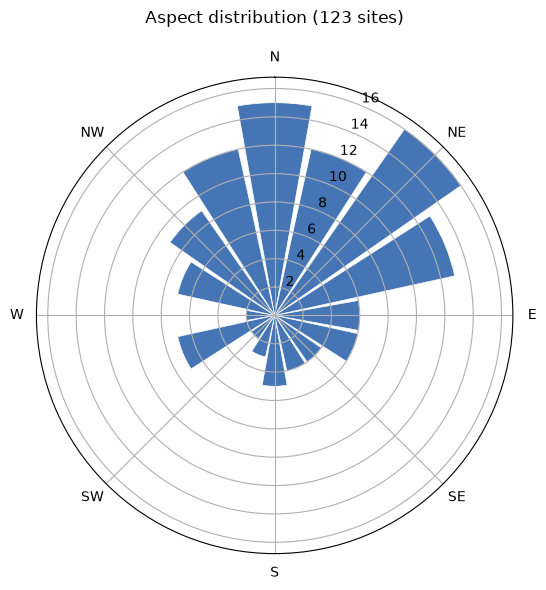

In [4]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="polar")
ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
totals = counts.sum(axis=1)
ax.bar(theta, totals, width=petal_width * 0.9, color="#4575b4",
       edgecolor="white", linewidth=0.5)
ax.set_xticks(np.deg2rad(np.arange(0, 360, 45)))
ax.set_xticklabels(["N", "NE", "E", "SE", "S", "SW", "W", "NW"])
ax.set_title(f"Aspect distribution ({len(gdf)} sites)", pad=20)
plt.tight_layout()
plt.show()

## Companion 2 — slope magnitude histogram

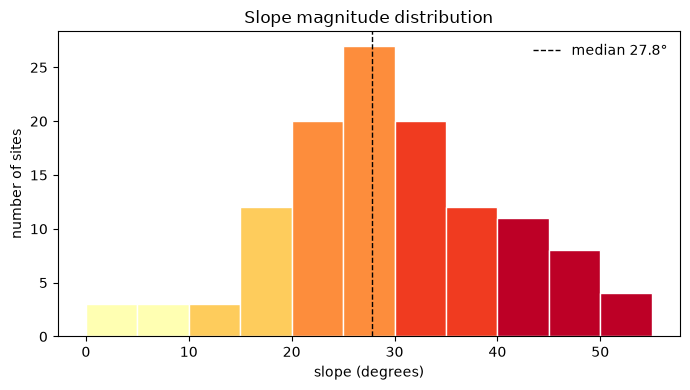

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
n, bins_, patches = ax.hist(gdf["slope_deg"], bins=np.arange(0, 60, 5),
                            edgecolor="white")
# color bars by slope class
for patch, left in zip(patches, bins_[:-1]):
    b = np.digitize(left + 2.5, SLOPE_BINS[1:-1])
    patch.set_facecolor(SLOPE_COLORS[min(b, len(SLOPE_COLORS) - 1)])
ax.axvline(gdf["slope_deg"].median(), color="k", ls="--", lw=1,
           label=f"median {gdf['slope_deg'].median():.1f}°")
ax.set_xlabel("slope (degrees)"); ax.set_ylabel("number of sites")
ax.set_title("Slope magnitude distribution")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## Companion 3 — scatter: does steepness vary with aspect?
Polar scatter, radius = slope. Reveals whether the steepest sites cluster in
certain directions.

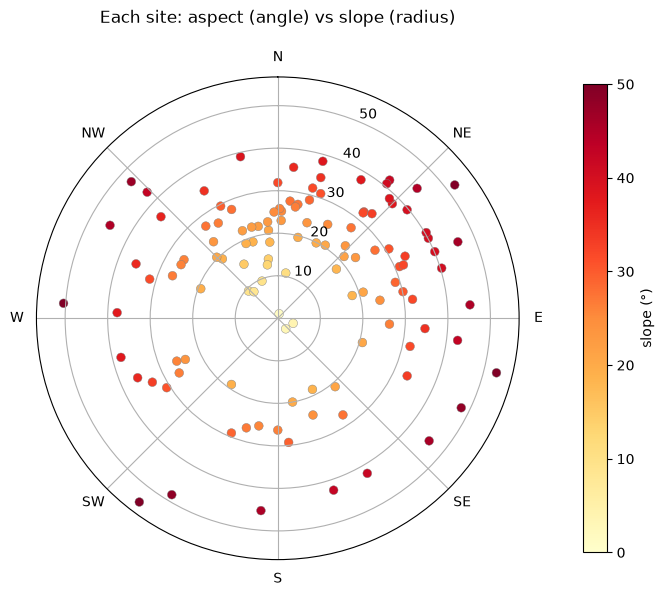

In [6]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="polar")
ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
sc = ax.scatter(np.deg2rad(gdf["aspect_deg"]), gdf["slope_deg"],
                c=gdf["slope_deg"], cmap="YlOrRd", s=40,
                edgecolor="gray", linewidth=0.3, vmin=0, vmax=50)
ax.set_xticks(np.deg2rad(np.arange(0, 360, 45)))
ax.set_xticklabels(["N", "NE", "E", "SE", "S", "SW", "W", "NW"])
ax.set_title("Each site: aspect (angle) vs slope (radius)", pad=20)
plt.colorbar(sc, label="slope (°)", pad=0.1, shrink=0.7)
plt.tight_layout()
plt.show()

## Summary table

In [7]:
summary = (gdf.groupby("aspect_dir")
           .agg(n=("site_no", "size"),
                slope_mean=("slope_deg", "mean"),
                slope_max=("slope_deg", "max"))
           .reindex(["N", "NE", "E", "SE", "S", "SW", "W", "NW"])
           .round(1))
print(summary)
print(f"\nAll sites: n={len(gdf)}, "
      f"slope median={gdf['slope_deg'].median():.1f}°, "
      f"mean={gdf['slope_deg'].mean():.1f}°, max={gdf['slope_deg'].max():.1f}°")

             n  slope_mean  slope_max
aspect_dir                           
N           28        24.3       39.0
NE          28        33.3       52.1
E           15        30.2       53.0
SE           8        29.9       48.0
S            9        29.9       45.4
SW           9        33.0       54.1
W            7        34.2       50.5
NW          19        26.0       47.1

All sites: n=123, slope median=27.8°, mean=29.3°, max=54.1°
